In [ ]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import shap
import matplotlib.pyplot as plt

2026-02-26 16:12:57.936028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772122378.164444      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772122378.226952      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772122378.757642      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772122378.757692      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772122378.757695      55 computation_placer.cc:177] computation placer alr

In [2]:
# ================================
# 2. Load Dataset
# ================================
dataset_path = "/kaggle/input/datasets/dhivyeshrk/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (246945, 378)
         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal involuntary mov

In [3]:
# ================================
# 3. Split Features & Target
# ================================
X = df.drop(columns=['diseases'])
y = df['diseases']

# Convert features to numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X = X.astype(np.float32)

print("Feature dtype check:", X.dtypes.unique())

Feature dtype check: [dtype('float32')]


In [4]:
# ================================
# 4. Encode Target Labels (IMPORTANT FIX)
# ================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))
print("Number of disease classes:", num_classes)

# ❗ SAFETY CHECK
assert num_classes > 1, "Dataset has only one disease class!"

Number of disease classes: 773


In [5]:
# Count disease occurrences
disease_counts = df['diseases'].value_counts()

print("Total diseases before filtering:", df['diseases'].nunique())
print(disease_counts.head())

Total diseases before filtering: 773
diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
Name: count, dtype: int64


In [6]:
MIN_SAMPLES = 2

valid_diseases = disease_counts[disease_counts >= MIN_SAMPLES].index

df = df[df['diseases'].isin(valid_diseases)]

print("Total diseases after filtering:", df['diseases'].nunique())
print("Dataset shape after filtering:", df.shape)

Total diseases after filtering: 754
Dataset shape after filtering: (246926, 378)


In [7]:
X = df.drop(columns=['diseases'])
y = df['diseases']

X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X = X.astype(np.float32)

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))
print("Final number of disease classes:", num_classes)

Final number of disease classes: 754


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [10]:
# ================================
# 6. Build MLP Model (FINAL & CORRECT)
# ================================
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')  # ✅ MULTI-CLASS FIX
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772122417.744590      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772122417.747545      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        96,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 754)            │        49,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,930 (730.20 KB)

 Trainable params: 186,930 (730.20 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ================================
# 8. Train Model
# ================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


I0000 00:00:1772122421.309796     121 service.cc:152] XLA service 0x7f666400b7c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772122421.309860     121 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772122421.309869     121 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772122421.666268     121 cuda_dnn.cc:529] Loaded cuDNN version 91002


  65/2778 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.0061 - loss: 6.5263    

I0000 00:00:1772122423.856545     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2778/2778 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.4004 - loss: 2.9339 - val_accuracy: 0.8094 - val_loss: 0.5961
Epoch 2/20
2778/2778 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7530 - loss: 0.8088 - val_accuracy: 0.8302 - val_loss: 0.4784
Epoch 3/20
2778/2778 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7843 - loss: 0.6805 - val_accuracy: 0.8397 - val_loss: 0.4449
Epoch 4/20
2778/2778 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7997 - loss: 0.6256 - val_accuracy: 0.8427 - val_loss: 0.4309
Epoch 5/20
2778/2778 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8067 - loss: 0.5896 - val_accuracy: 0.8444 - val_loss: 0.4254
Epoch 6/20
2778/2778 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8123 - loss: 0.5701 - val_accuracy: 0.8471 - val_loss: 0.4174
Epoch 7/20
2778/2778 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8160 - loss: 0.5595 - val_accuracy: 0.8475 - val_loss: 0.4084
Epoch 8/20
2778/2778 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8199 - loss: 0.5416 - val_accura

In [12]:
# ================================
# 9. Evaluate Model
# ================================
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

1544/1544 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Accuracy: 0.8571457498076378

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      0.90      0.95        81
           2       0.85      0.88      0.86        58
           3       0.80      1.00      0.89         4
           4       0.94      0.85      0.89        68
           5       0.55      1.00      0.71         6
           6       1.00      0.86      0.92         7
           7       0.74      0.82      0.78        17
           8       0.88      0.70      0.78        99
           9       0.87      0.76      0.81       182
          10       0.96      0.91      0.94       241
          11       0.94      0.69      0.80       243
          12       0.68      0.72      0.70       181
          13       0.50      1.00      0.67         2
          14       0.52      0.40      0.45        42
          15       0.98      0.96    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [18]:
!pip install shap

In [19]:
import shap
import numpy as np

# Convert to numpy
X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

# Background samples
background = X_train_np[np.random.choice(
    X_train_np.shape[0], 100, replace=False
)]

# ✅ Pass model directly (DO NOT wrap)
explainer = shap.GradientExplainer(
    model,
    background
)

# Explain 50 samples
X_shap = X_test_np[:50]

shap_values = explainer.shap_values(X_shap)

SHAP Summary for abdominal aortic aneurysm


/tmp/ipykernel_55/92264656.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


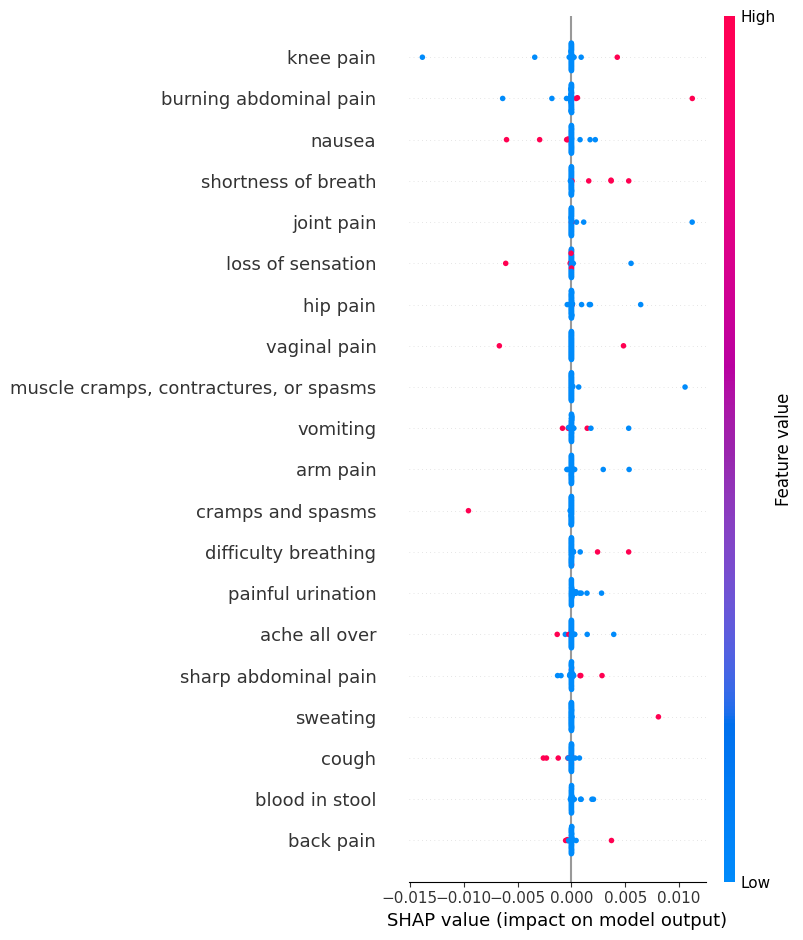

SHAP Summary for abdominal hernia


/tmp/ipykernel_55/92264656.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


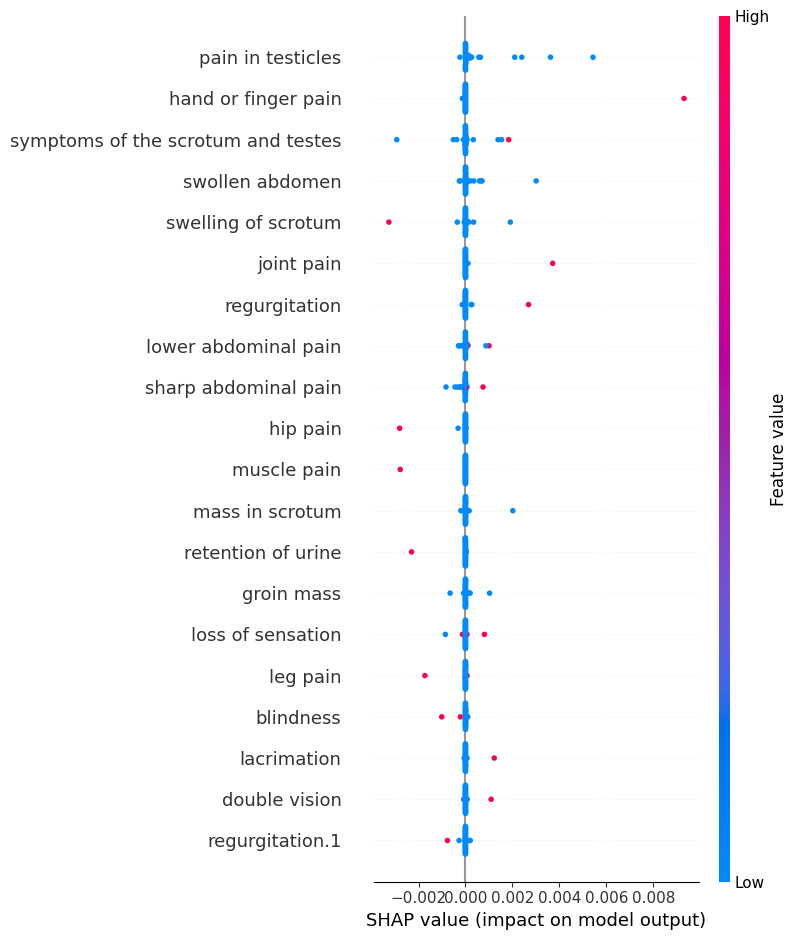

SHAP Summary for abscess of nose


/tmp/ipykernel_55/92264656.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


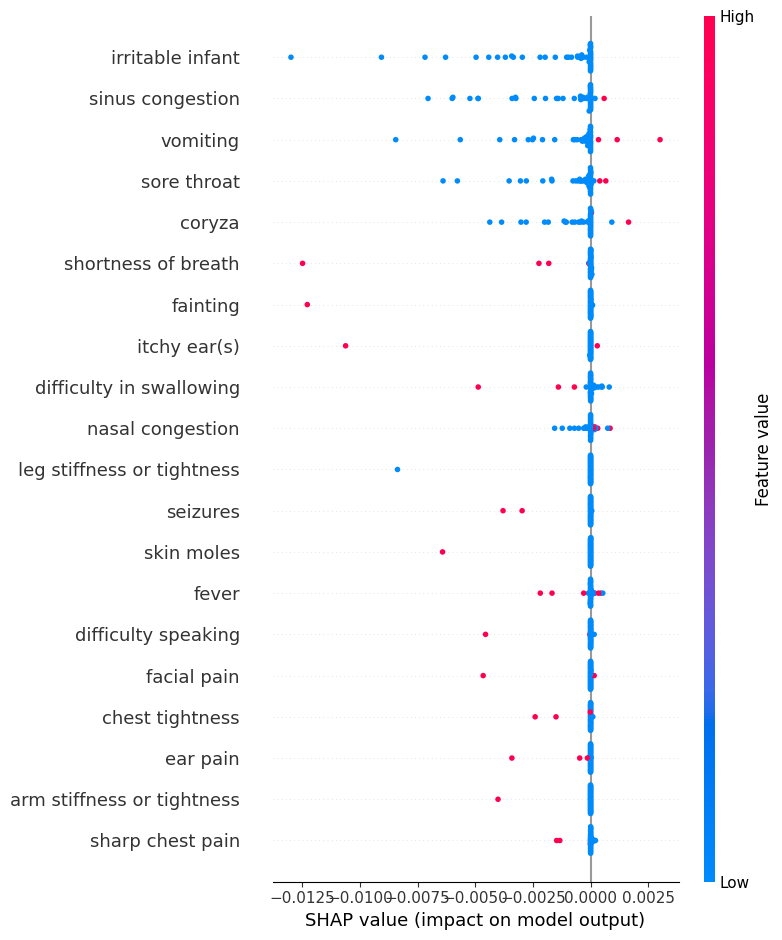

SHAP Summary for abscess of the lung


/tmp/ipykernel_55/92264656.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


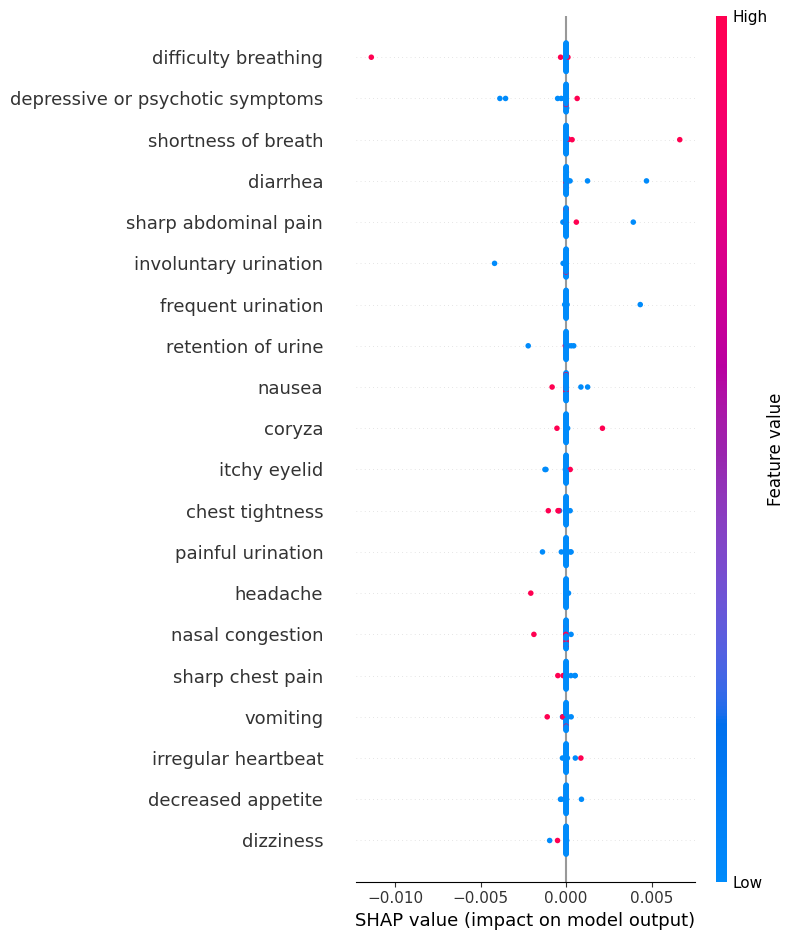

SHAP Summary for abscess of the pharynx


/tmp/ipykernel_55/92264656.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


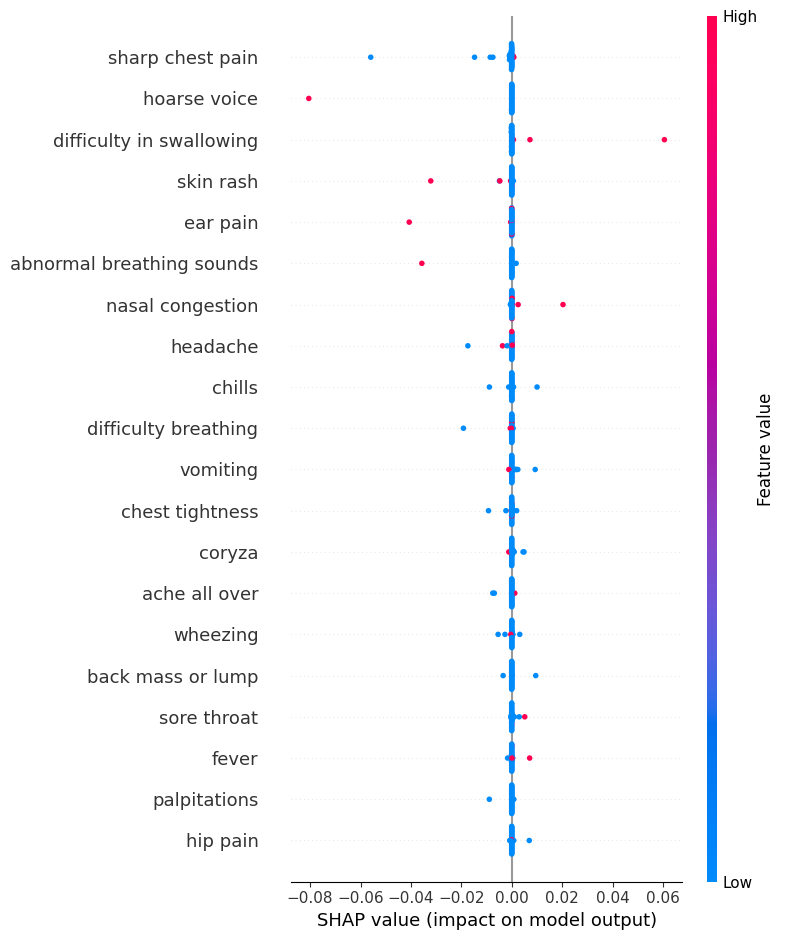

In [21]:
for i, class_name in enumerate(label_encoder.classes_[:5]):
    print(f"SHAP Summary for {class_name}")

    shap.summary_plot(
        shap_values[:, :, i],   # ← correct slicing
        X_shap,
        feature_names=X.columns
    )